In [ ]:

# Cell 1: Imports & config
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import KFold
from tensorflow.keras import layers as L, Model

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Paths (KEEP EXACT as provided)
DATASET_PATH = "/content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/Image_to_height_v2/dataset_1024.npz"
# Data & training config (kept intact from your prompt)
BATCH_SIZE   = 64
RESIZE_SHAPE = (224, 224)     # ResNet50 default
N_FOLDS      = 103
AUTOTUNE     = tf.data.AUTOTUNE

# Augmenter strength (adjust if you want)
ROT_MAX = 0.05    # ~±5% radians
ZOOM    = 0.10    # 10% zoom

print("Config ready.")

Config ready.


In [ ]:
# Cell 2: Load data
data = np.load(DATASET_PATH)
X = data["X"]   # (N, H, W, 3) uint8
Y = data["Y"]   # (N,) float

print("Loaded dataset.")
print(f"Original X: {X.shape}, dtype={X.dtype}")
print(f"Original Y: {Y.shape}, dtype={Y.dtype}")

# ---- Exclude multiple bad samples ----
bad_indices = {1, 35, 44, 31, 38, 11, 32, 30, 78, 42, 29, 28}

mask = np.array([i not in bad_indices for i in range(len(X))])

X = X[mask]
Y = Y[mask]

print(f"Removed samples at indices: {sorted(list(bad_indices))}")
print(f"New X: {X.shape}")
print(f"New Y: {Y.shape}")



Loaded dataset.
Original X: (103, 1024, 1024, 3), dtype=uint8
Original Y: (103,), dtype=float32
Removed samples at indices: [1, 8, 11, 15, 28, 29, 30, 31, 32, 35, 38, 42, 44, 45, 48, 78, 82, 98]
New X: (85, 1024, 1024, 3)
New Y: (85,)


In [ ]:
# Cell 3: Preprocess & augmenter
def preprocess(x, y):
    # keep 0..255 scale for resnet preprocess
    x = tf.cast(x, tf.float32)
    x = tf.image.resize(x, RESIZE_SHAPE, method="bilinear")
    y = tf.cast(y, tf.float32)
    return x, y

def build_augmenter():
    return tf.keras.Sequential([
        L.RandomFlip("horizontal"),
        # # OPTIONAL augmentations:
        # L.RandomRotation(ROT_MAX),                          # small rotation
        # L.RandomZoom((-ZOOM, 0.0), (-ZOOM, 0.0)),           # zoom out only
        # L.RandomTranslation(0.05, 0.05),                    # slight shift
        # L.RandomContrast(0.1),
        # L.RandomBrightness(0.1),
        # L.RandomSaturation(0.1),
        # L.RandomHue(0.05),
    ])

AUG = build_augmenter()
print("Preprocess and augmenter ready.")


Preprocess and augmenter ready.


In [ ]:
# Cell 4: tf.data builder
def make_dataset(X_np, Y_np, batch_size=BATCH_SIZE, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X_np, Y_np))
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (AUG(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

print("make_dataset defined.")


make_dataset defined.


In [ ]:
# Cell 5: Model builder
def build_resnet50_regressor():
    inputs = L.Input(shape=(*RESIZE_SHAPE, 3))
    # Keras preprocessing for ResNet50
    x = L.Lambda(tf.keras.applications.resnet50.preprocess_input)(inputs)

    base = tf.keras.applications.ResNet50(
        include_top=False, weights="imagenet", input_tensor=x
    )
    base.trainable = False  # Stage 1: freeze

    x = L.GlobalAveragePooling2D()(base.output)
    x = L.Dropout(0.2)(x)
    outputs = L.Dense(1, activation="linear")(x)

    model = Model(inputs, outputs)
    return model, base

print("Model builder ready.")


Model builder ready.


In [ ]:
# Cell 6: Unfreeze helper
def unfreeze_last_k_non_bn_layers(base, k=80):
    unfrozen = 0
    for layer in reversed(base.layers):
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
            continue
        if unfrozen < k:
            layer.trainable = True
            unfrozen += 1
        else:
            layer.trainable = False
    return unfrozen

print("Unfreeze helper ready.")


Unfreeze helper ready.


In [ ]:
# Cell 7: Callbacks helper (you can continue using your existing make_callbacks if you prefer)
def make_callbacks(out_dir, fold, stage):
    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = os.path.join(out_dir, f"fold{fold:02d}_stage{stage}.keras")
    return [
        tf.keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_mae", save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae", factor=0.5, patience=3, min_lr=1e-6, verbose=1
        ),
    ]

print("Callbacks helper ready.")


Callbacks helper ready.


In [ ]:
# Replace your current function with this block (LOO CV with visible training progress).
from sklearn.model_selection import LeaveOneOut

def run_kfold_cv_resnet50(
    X, Y, seed=SEED,
    out_dir="/content/drive/MyDrive/Thesis/anthrovision_v1/results/cv_resnet50_leave_one_out_validation_last80FT",
    stage1_epochs=20, stage2_epochs=40, n_unfreeze=80, batch_size=BATCH_SIZE,
    earlystop_patience=8, verbose=True
):
    """
    True Leave-One-Out CV (resumes on restart). Saves best stage-2 weights per fold and
    saves validation images with overlay text (fold, actual, pred).

    Loss: Mean Squared Error (MSE).
    Verbosity controlled by `verbose` (True -> show Keras training progress bars and callback messages).
    """
    os.makedirs(out_dir, exist_ok=True)
    pred_dir = os.path.join(out_dir, "pred_images")
    os.makedirs(pred_dir, exist_ok=True)
    weights_dir = os.path.join(out_dir, "weights")
    os.makedirs(weights_dir, exist_ok=True)
    progress_path = os.path.join(out_dir, "progress.json")

    # load progress if exists
    if os.path.exists(progress_path):
        with open(progress_path, "r") as f:
            prog = json.load(f)
            completed_folds = set(prog.get("completed_folds", []))
    else:
        completed_folds = set()

    n_samples = len(X)
    loo = LeaveOneOut()
    fold_rows = []

    total_folds = n_samples
    print(f"Starting Leave-One-Out CV with {n_samples} folds (one sample per fold). Verbose={verbose}")
    for fold, (tr_idx, va_idx) in enumerate(loo.split(X), start=1):
        # va_idx is shape (1,) — the global index of the single validation sample
        if fold in completed_folds:
            if verbose and (fold % 100 == 0 or fold <= 5):
                print(f"Skipping fold {fold} (already completed).")
            continue

        if verbose and (fold % 50 == 1 or fold <= 5):
            # occasional progress print to avoid too much logging
            print(f"\n========== Fold {fold}/{total_folds} ==========")

        X_tr, Y_tr = X[tr_idx], Y[tr_idx]
        X_va, Y_va = X[va_idx], Y[va_idx]

        # Datasets: train uses batch_size, val uses batch_size=1 to preserve sample-level preds
        train_ds = make_dataset(X_tr, Y_tr, batch_size=batch_size, training=True)
        val_ds   = make_dataset(X_va, Y_va, batch_size=1, training=False)

        # ---- Stage 1: train head (frozen base) using MSE
        model, base = build_resnet50_regressor()
        mse_loss = tf.keras.losses.MeanSquaredError()
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss=mse_loss, metrics=["mae"])

        # Stage1 callbacks: save stage1 weights (weights only)
        stage1_ckpt = os.path.join(weights_dir, f"fold{fold:05d}_stage1.weights.h5")
        cb_stage1 = [
            tf.keras.callbacks.ModelCheckpoint(stage1_ckpt, monitor="val_mae",
                                               save_best_only=True, save_weights_only=True,
                                               verbose=1 if verbose else 0),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=10, min_lr=1e-6,
                                                 verbose=1 if verbose else 0)
        ]
        # Run stage1
        if verbose:
            print(f"Fold {fold}: Stage 1 (train head) for {stage1_epochs} epochs.")
        model.fit(train_ds, validation_data=val_ds, epochs=stage1_epochs, callbacks=cb_stage1,
                  verbose=1 if verbose else 0)

        # ---- Stage 2: fine-tune last k non-BN layers (MSE)
        n_unfrozen = unfreeze_last_k_non_bn_layers(base, k=n_unfreeze)
        if verbose and (fold <= 5 or fold % 100 == 1):
            print(f"Unfroze {n_unfrozen} non-BN layers for fine-tuning (fold {fold}).")

        mse_loss_stage2 = tf.keras.losses.MeanSquaredError()
        model.compile(optimizer=tf.keras.optimizers.Adam(3e-5),
                      loss=mse_loss_stage2, metrics=["mae"])

        # Save best weights (weights-only) and earlystop
        best_w_path = os.path.join(weights_dir, f"fold{fold:05d}_best.weights.h5")
        ckpt = tf.keras.callbacks.ModelCheckpoint(best_w_path, monitor="val_mae",
                                                  save_best_only=True, save_weights_only=True,
                                                  verbose=1 if verbose else 0)
        es = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=earlystop_patience,
                                              restore_best_weights=True, verbose=1 if verbose else 0)
        redlr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=3, min_lr=1e-6,
                                                     verbose=1 if verbose else 0)

        if verbose:
            print(f"Fold {fold}: Stage 2 (fine-tune) for up to {stage2_epochs} epochs.")
        hist = model.fit(train_ds, validation_data=val_ds, epochs=stage2_epochs,
                         callbacks=[ckpt, es, redlr], verbose=1 if verbose else 0)

        # Defensive reload best weights if available
        if os.path.exists(best_w_path):
            try:
                model.load_weights(best_w_path)
            except Exception as e:
                print(f"Warning: couldn't reload best weights for fold {fold}: {e}")

        # ---- Predict on validation sample (val_ds has single sample)
        preds = model.predict(val_ds)
        preds = np.squeeze(np.array(preds)).reshape(-1)  # shape = (1,)
        trues = np.squeeze(np.array(Y_va)).reshape(-1)   # shape = (1,)

        # Record per-fold aggregated metric (from history)
        best_val_mae  = float(np.min(hist.history.get("val_mae", [np.nan])))
        val_rmse = float(np.sqrt(np.mean((preds - trues) ** 2)))
        fold_rows.append({"fold": fold, "val_mae": best_val_mae, "val_rmse": val_rmse,
                          "global_val_idx": int(va_idx[0]), "actual": float(trues[0]), "pred": float(preds[0])})

        # ---- Save validation image overlay for this sample
        idx_global = int(va_idx[0])
        true_val = float(trues[0])
        pred_val = float(preds[0])

        # load image (X may be arrays or filepaths)
        try:
            img = X_va[0]
            if isinstance(img, (str, os.PathLike)):
                im = plt.imread(img)
            else:
                im = img
        except Exception as e:
            print(f"Warning: could not load validation image for fold {fold}, idx {idx_global}: {e}")
            im = None

        fig, ax = plt.subplots(figsize=(4,4))
        if im is not None:
            ax.imshow(im)
            ax.axis("off")
            h_px = im.shape[0]
        else:
            ax.text(0.5, 0.5, "Image unavailable", ha='center', va='center')
            ax.axis("off")
            h_px = 200

        overlay_text = (
            f"Fold: {fold}\n"
            f"Idx:  {idx_global}\n"
            f"Actual: {true_val:.2f} cm\n"
            f"Pred:   {pred_val:.2f} cm"
        )
        ax.text(5, h_px - 10, overlay_text,
                fontsize=10, color='white', ha='left', va='bottom',
                bbox=dict(boxstyle="round,pad=0.3", fc='black', alpha=0.6))

        out_png = os.path.join(pred_dir, f"fold_{fold:05d}_idx_{idx_global:04d}.png")
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        plt.close(fig)

        # ---- Update progress checkpoint and free memory
        completed_folds.add(fold)
        # store completed folds as sorted list to keep file small and readable
        with open(progress_path, "w") as f:
            json.dump({"completed_folds": sorted(list(completed_folds))}, f)

        if verbose and (fold % 50 == 0 or fold <= 5):
            print(f"Fold {fold} done. Saved validation image to {out_png} and best weights to {best_w_path}.")

        # Clear session to free GPU memory (important for long runs)
        tf.keras.backend.clear_session()

    # ---- Summarize CV
    df = pd.DataFrame(fold_rows)
    if len(df) > 0:
        mean_row = {"fold": "mean", "val_mae": df.val_mae.mean(), "val_rmse": df.val_rmse.mean()}
        std_row  = {"fold": "std",  "val_mae": df.val_mae.std(),  "val_rmse": df.val_rmse.std()}
        df_summary = pd.concat([df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
    else:
        df_summary = pd.DataFrame()

    csv_path = os.path.join(out_dir, "cv_summary_leave_one_out.csv")
    df_summary.to_csv(csv_path, index=False)
    print("\nLOO CV summary saved to:", csv_path)
    return df_summary

print("Leave-One-Out function defined.")


Leave-One-Out function defined.


In [ ]:
# Cell 9: Run the CV
# NOTE: ensure Google Drive is mounted if out_dir is on Drive.
out_dir = "/content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT"   # change if you prefer another path (or a Drive path)
cv_summary = run_kfold_cv_resnet50(
    X, Y, seed=SEED, out_dir=out_dir,
    stage1_epochs=20, stage2_epochs=40, n_unfreeze=80,
    batch_size=BATCH_SIZE, earlystop_patience=8
)

print("Done. Summary:")
print(cv_summary)


Starting Leave-One-Out CV with 91 folds (one sample per fold). Verbose=True
Skipping fold 1 (already completed).
Skipping fold 2 (already completed).
Skipping fold 3 (already completed).
Skipping fold 4 (already completed).
Skipping fold 5 (already completed).
Fold 72: Stage 1 (train head) for 20 epochs.
Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 17581.3164 - mae: 132.0804  
Epoch 1: val_mae improved from inf to 127.01776, saving model to /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT/weights/fold00072_stage1.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 11s/step - loss: 17447.3770 - mae: 131.5716 - val_loss: 16133.5117 - val_mae: 127.0178 - learning_rate: 0.0010
Epoch 2/20
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 17393.1934 - mae: 131.3736
Epoch 2: val_mae improved from 127.01776 to 124.41460, saving model to /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Fold 77: Stage 1 (train head) for 20 epochs.
Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 17464.4492 - mae: 131.6467  
Epoch 1: val_mae improved from inf to 125.07558, saving model to /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT/weights/fold00077_stage1.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - loss: 17343.4570 - mae: 131.1891 - val_loss: 15643.9014 - val_mae: 125.0756 - learning_rate: 0.0010
Epoch 2/20
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 17238.5469 - mae: 130.7750
Epoch 2: val_mae improved from 125.07558 to 122.87830, saving model to /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT/weights/fold00077_stage1.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step - loss: 16744.6738 - mae: 128.8759 - val_loss: 15099.0771 - val_mae: 122.8783 - learning_rate: 0.0010
Epoch 3/20
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Fold 78: Stage 1 (train head) for 20 epochs.
Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 17405.0352 - mae: 131.4352  
Epoch 1: val_mae improved from inf to 123.61044, saving model to /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT/weights/fold00078_stage1.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - loss: 17274.2812 - mae: 130.9372 - val_loss: 15279.5420 - val_mae: 123.6104 - learning_rate: 0.0010
Epoch 2/20
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 17209.1836 - mae: 130.6885
Epoch 2: val_mae improved from 123.61044 to 121.51208, saving model to /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT/weights/fold00078_stage1.weights.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step - loss: 16673.7012 - mae: 128.6072 - val_loss: 14765.1865 - val_mae: 121.5121 - learning_rate: 0.0010
Epoch 3/20
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/ste

In [ ]:
# Recovery script: correct masked dataset mapping + load weights + run predictions

import os
import numpy as np
import pandas as pd
import tensorflow as tf

# -------------------------
# USER CONFIG
# -------------------------
OUT_DIR = "/content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT"
WEIGHTS_DIR = os.path.join(OUT_DIR, "weights")
CSV_OUT = os.path.join(OUT_DIR, "recovered_full_loo_predictions.csv")

REMOVED = {1, 35, 44, 31, 38, 11, 32, 30, 78, 42, 29, 28}   # your removed samples
USE_STAGE1_FALLBACK = True
VERBOSE = True

print("Weights directory:", WEIGHTS_DIR)

# -------------------------
# Load original dataset
# -------------------------
data = np.load(DATASET_PATH)
X_orig = data["X"]
Y_orig = data["Y"]
N_orig = len(X_orig)
print(f"Loaded original dataset: {N_orig} samples")

# -------------------------
# Build masked → original index mapping
# -------------------------
masked_to_original = [i for i in range(N_orig) if i not in REMOVED]
N_masked = len(masked_to_original)
print(f"After masking, {N_masked} samples remain.")

# LOO folds = #masked samples
print("Total expected folds:", N_masked)

# -------------------------
# Build masked dataset (must match training!)
# -------------------------
mask_arr = np.array([i not in REMOVED for i in range(N_orig)])
X = X_orig[mask_arr]
Y = Y_orig[mask_arr]

# -------------------------
# Recovery output table
# -------------------------
rows = []

for fold in range(1, N_masked + 1):

    masked_val_idx = fold - 1
    orig_idx = masked_to_original[masked_val_idx]

    row = {
        "fold": fold,
        "masked_idx": masked_val_idx,
        "original_idx": orig_idx,
        "pred": np.nan,
        "actual": float(Y_orig[orig_idx]),
        "abs_err": np.nan,
        "signed_err": np.nan,
        "rmse": np.nan,
        "notes": ""
    }

    # -------------------------
    # Weight file resolution
    # -------------------------
    best_w = os.path.join(WEIGHTS_DIR, f"fold{fold:05d}_best.weights.h5")
    stage1_w = os.path.join(WEIGHTS_DIR, f"fold{fold:05d}_stage1.weights.h5")

    if os.path.exists(best_w):
        chosen_w = best_w
        row["notes"] = "best"
    elif USE_STAGE1_FALLBACK and os.path.exists(stage1_w):
        chosen_w = stage1_w
        row["notes"] = "stage1_fallback"
    else:
        row["notes"] = "weights_missing"
        rows.append(row)
        if VERBOSE:
            print(f"[Fold {fold}] Missing weight file.")
        continue

    # -------------------------
    # Build model and load weights
    # -------------------------
    try:
        model, base = build_resnet50_regressor()
        model.load_weights(chosen_w)
    except Exception as e:
        row["notes"] = f"load_failed: {e}"
        rows.append(row)
        continue

    # -------------------------
    # Predict for the *masked* dataset index
    # -------------------------
    X_val = X[masked_val_idx:masked_val_idx+1]
    Y_val = Y[masked_val_idx:masked_val_idx+1]
    val_ds = make_dataset(X_val, Y_val, batch_size=1, training=False)

    pred = float(np.squeeze(model.predict(val_ds)))
    actual = float(Y_val[0])

    # -------------------------
    # Metrics
    # -------------------------
    row["pred"] = pred
    row["actual"] = actual
    row["abs_err"] = abs(pred - actual)
    row["signed_err"] = pred - actual
    row["rmse"] = float(np.sqrt((pred - actual)**2))

    rows.append(row)

    if VERBOSE and (fold <= 5 or fold % 50 == 0):
        print(f"[Fold {fold}] original_idx={orig_idx} pred={pred:.2f} actual={actual:.2f} err={abs(pred-actual):.2f}")

    tf.keras.backend.clear_session()


# -------------------------
# Save results
# -------------------------
df = pd.DataFrame(rows)
df.to_csv(CSV_OUT, index=False)
print("Saved:", CSV_OUT)

print("\nSummary of recovered predictions:")
print(df[["abs_err"]].describe())


Weights directory: /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT/weights
Loaded original dataset: 103 samples
After masking, 91 samples remain.
Total expected folds: 91
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[Fold 1] original_idx=0 pred=131.00 actual=130.00 err=1.00
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[Fold 2] original_idx=2 pred=139.88 actual=140.00 err=0.12
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[Fold 3] original_idx=3 pred=152.46 actual=151.00 err=1.46
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[Fold 4] original_idx=4 pred=149.21 actual=148.50 err=0.71
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[Fold 5] original_idx=5 pred=144.09 actual=144.50 err=0.41
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━

Using CSV: /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT/recovered_full_loo_predictions.csv
Preview (first 10 rows):


,fold,masked_idx,original_idx,pred,actual,abs_err,signed_err,rmse,notes
0,1,0,0,131.004364,130.0,1.004364,1.004364,1.004364,best
1,2,1,2,139.881546,140.0,0.118454,-0.118454,0.118454,best
2,3,2,3,152.458557,151.0,1.458557,1.458557,1.458557,best
3,4,3,4,149.214981,148.5,0.714981,0.714981,0.714981,best
4,5,4,5,144.087952,144.5,0.412048,-0.412048,0.412048,best
5,6,5,6,155.695526,156.0,0.304474,-0.304474,0.304474,best
6,7,6,7,149.767792,149.0,0.767792,0.767792,0.767792,best
7,8,7,8,135.108826,142.0,6.891174,-6.891174,6.891174,best
8,9,8,9,145.264954,145.0,0.264954,0.264954,0.264954,best
9,10,9,10,132.892319,150.0,17.107681,-17.107681,17.107681,best


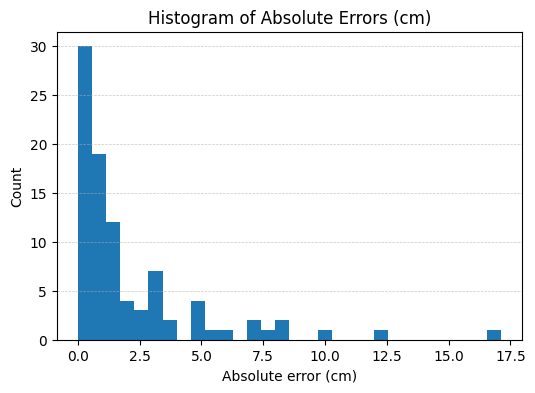

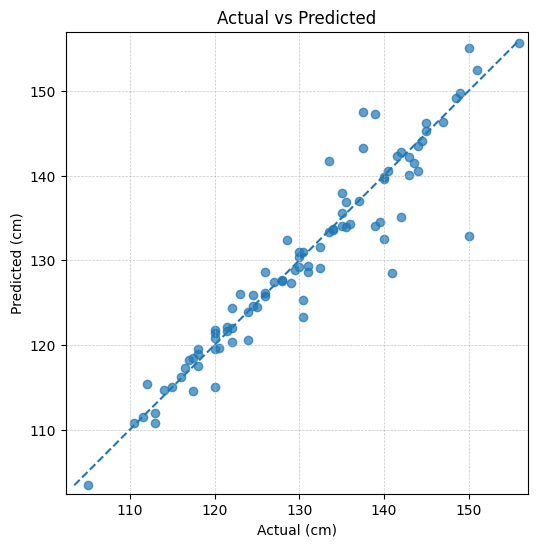

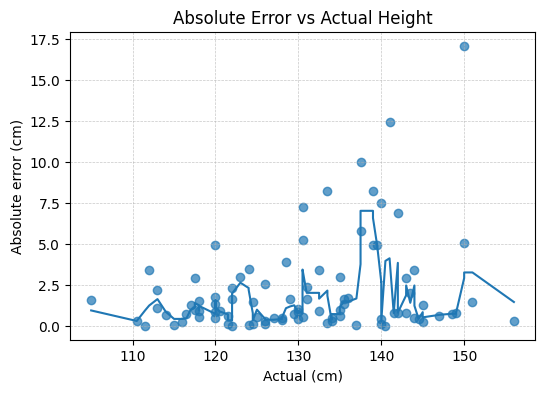

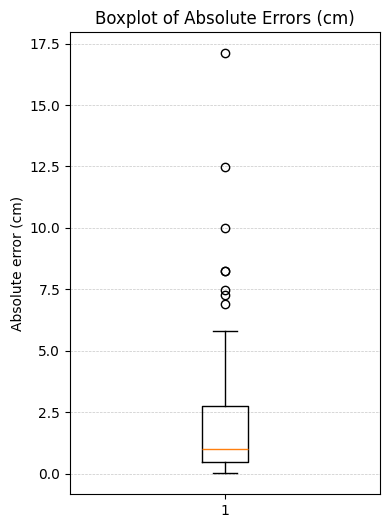

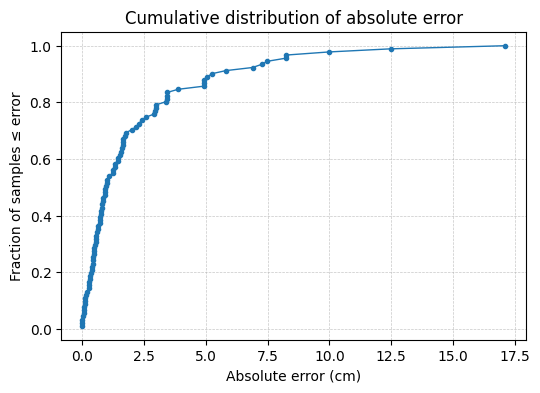

Saved example plot to: /content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_last80FT/recovered_plots_abs_err_hist.png


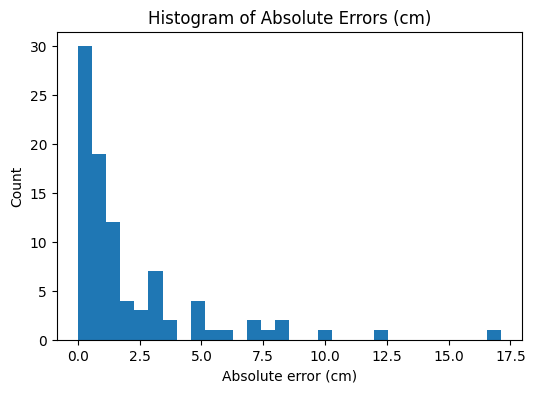

In [ ]:
# Searching for the recovered CSV, loading it, showing a preview, and creating visualizations.
# This cell will:
# 1. find the CSV under your Drive Theses folder (flexible search)
# 2. load it into a DataFrame and display the head (interactive table)
# 3. plot:
#    - histogram of absolute errors
#    - scatter Actual vs Predicted with y=x reference line
#    - scatter Absolute Error vs Actual (to see error vs height)
#    - boxplot of errors
#    - optional cumulative error plot (sorted abs error)
#
# Notes: uses matplotlib (no seaborn), one plot per figure, and ace_tools.display_dataframe_to_user
# If multiple recovered CSVs are found, the first matching file is used.

import glob, os, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# helper from notebook environment (ace_tools may be available)
try:
    from ace_tools import display_dataframe_to_user
    have_ace = True
except Exception:
    have_ace = False

# Flexible search base directories to check
search_bases = [ "/content/drive/MyDrive/Thesis/New Exp: on Image_to_height_v2/cv_resnet50_leave_one_out_validation_v3_last80FT/recovered_full_loo_predictions.csv" ]

candidates = []
for base in search_bases:
    if os.path.isdir(base):
        candidates.extend(glob.glob(os.path.join(base, "**", "recovered_full_loo_predictions*.csv"), recursive=True))

# If still empty, try a looser pattern anywhere in MyDrive
if len(candidates) == 0 and os.path.isdir("/content/drive/MyDrive"):
    candidates = glob.glob("/content/drive/MyDrive/**/recovered_full_loo_predictions*.csv", recursive=True)

if len(candidates) == 0:
    print("No recovered_full_loo_predictions CSV found under the searched paths.")
    print("You can provide the exact path or place the file under your Drive. Searched bases:", search_bases)
else:
    csv_path = sorted(candidates)[0]
    print("Using CSV:", csv_path)
    df = pd.read_csv(csv_path)
    # Ensure numeric columns
    for col in ["pred", "actual", "abs_err", "rmse"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Display dataframe preview in a friendly way
    if have_ace:
        display_dataframe_to_user("Recovered LOO predictions (preview)", df.head(200))
    else:
        print("Preview (first 10 rows):")
        display(df.head(10))

    # Prepare cleaned df for plotting (only rows with numeric predictions)
    plot_df = df[df["notes"].notnull()].copy()
    if "abs_err" in plot_df.columns:
        plot_df = plot_df[~plot_df["abs_err"].isna()]
    else:
        # compute if missing
        if "pred" in plot_df.columns and "actual" in plot_df.columns:
            plot_df["abs_err"] = (plot_df["pred"] - plot_df["actual"]).abs()
        else:
            raise RuntimeError("CSV doesn't have pred/actual columns needed for plots.")

    # --- Plot 1: Histogram of absolute errors ---
    plt.figure(figsize=(6,4))
    plt.hist(plot_df["abs_err"].values, bins=30)
    plt.title("Histogram of Absolute Errors (cm)")
    plt.xlabel("Absolute error (cm)")
    plt.ylabel("Count")
    plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.show()

    # --- Plot 2: Actual vs Predicted scatter ---
    plt.figure(figsize=(6,6))
    x = plot_df["actual"].values
    y = plot_df["pred"].values
    plt.scatter(x, y, alpha=0.7)
    mn = min(np.nanmin(x), np.nanmin(y))
    mx = max(np.nanmax(x), np.nanmax(y))
    plt.plot([mn, mx], [mn, mx], linestyle='--')  # y=x reference
    plt.title("Actual vs Predicted")
    plt.xlabel("Actual (cm)")
    plt.ylabel("Predicted (cm)")
    plt.xlim(mn - 1, mx + 1)
    plt.ylim(mn - 1, mx + 1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.show()

    # --- Plot 3: Absolute error vs Actual ---
    plt.figure(figsize=(6,4))
    plt.scatter(plot_df["actual"].values, plot_df["abs_err"].values, alpha=0.7)
    # overlay a smooth rolling median to visualize trend
    try:
        sorted_df = plot_df.sort_values("actual")
        window = max(3, int(len(sorted_df) * 0.05))
        rm = sorted_df["abs_err"].rolling(window, center=True, min_periods=1).median()
        plt.plot(sorted_df["actual"].values, rm.values, linestyle='-')
    except Exception:
        pass
    plt.title("Absolute Error vs Actual Height")
    plt.xlabel("Actual (cm)")
    plt.ylabel("Absolute error (cm)")
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.show()

    # --- Plot 4: Boxplot of absolute errors ---
    plt.figure(figsize=(4,6))
    plt.boxplot(plot_df["abs_err"].values, vert=True)
    plt.title("Boxplot of Absolute Errors (cm)")
    plt.ylabel("Absolute error (cm)")
    plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.show()

    # --- Plot 5: Cumulative error curve (sorted abs errors) ---
    plt.figure(figsize=(6,4))
    sorted_err = np.sort(plot_df["abs_err"].values)
    cum = np.arange(1, len(sorted_err)+1) / len(sorted_err)
    plt.plot(sorted_err, cum, marker='.', linewidth=1)
    plt.xlabel("Absolute error (cm)")
    plt.ylabel("Fraction of samples ≤ error")
    plt.title("Cumulative distribution of absolute error")
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.show()

    # Save basic plots to OUT_DIR if desired
    save_dir = os.path.dirname(csv_path)
    save_prefix = os.path.join(save_dir, "recovered_plots")
    try:
        # save last figure as example; user can modify to save all
        plt.figure(figsize=(6,4))
        plt.hist(plot_df["abs_err"].values, bins=30)
        plt.title("Histogram of Absolute Errors (cm)")
        plt.xlabel("Absolute error (cm)")
        plt.ylabel("Count")
        plt.savefig(save_prefix + "_abs_err_hist.png", bbox_inches="tight", dpi=150)
        print("Saved example plot to:", save_prefix + "_abs_err_hist.png")
    except Exception as e:
        print("Couldn't save example plot:", e)


